# CNN - EfficientNetB0
Bài toán phân loại ảnh chim (150 lớp) sử dụng EfficientNetB0 với Transfer Learning.

In [9]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from google.colab import drive
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Load Dataset

In [10]:
drive.mount('/content/drive')

PATH_AUGMENTED_ZIP  = '/content/drive/MyDrive/CS231/augmented_dataset.zip'
EXTRACT_DIR_AUG   = '/content/augmented_dataset'

def extract_zip(zip_path, extract_path):
    if not os.path.exists(zip_path):
        print(f'LOI: Khong tim thay file {zip_path}.')
        return
    if not os.path.exists(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        print(f'Dang giai nen {zip_path}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f'Giai nen xong: {extract_path}')
    else:
        print(f'Thu muc da ton tai: {extract_path}')

extract_zip(PATH_AUGMENTED_ZIP, EXTRACT_DIR_AUG)

AUG_PATH = {
    'train': os.path.join(EXTRACT_DIR_AUG, 'train'),
    'val':   os.path.join(EXTRACT_DIR_AUG, 'val'),
    'test':  os.path.join(EXTRACT_DIR_AUG, 'test')
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thu muc da ton tai: /content/augmented_dataset


## Build Model - EfficientNetB0

In [11]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.models import Model

def build_efficientnetb0(input_shape=(224, 224, 3), num_classes=150):

    input_tensor = Input(shape=input_shape)

    backbone = EfficientNetB0(include_top=False,
                              weights=None,
                              input_tensor=input_tensor)

    backbone.trainable = True

    x = backbone.output

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=input_tensor, outputs=output)

model = build_efficientnetb0(input_shape=(224, 224, 3), num_classes=150)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ normalization_2[… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_

 Total params: 4,246,841 (16.20 MB)

 Trainable params: 4,202,258 (16.03 MB)

 Non-trainable params: 44,583 (174.16 KB)

## Hàm Đánh Giá và Vẽ Biểu Đồ

In [12]:
def evaluate_and_plot(model, test_generator, title="Model Evaluation"):
    test_generator.reset()
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)
    pre, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    print(f"\n--- {title} ---")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_training_history(history, title="EfficientNetB0"):
    acc     = history.history.get('accuracy', history.history.get('acc'))
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
    loss     = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'Loss - {title}')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(); plt.show()

def plot_sample_predictions(model, test_generator, num_samples=5):
    test_generator.reset()
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())

    correct_idx   = np.where(y_pred == y_true)[0]
    incorrect_idx = np.where(y_pred != y_true)[0]

    def draw_grid(indices, status_title):
        plt.figure(figsize=(20, 5))
        plt.suptitle(f"Ví dụ dự đoán {status_title}", fontsize=16, fontweight='bold')
        selected = np.random.choice(indices, min(num_samples, len(indices)), replace=False)
        for i, idx in enumerate(selected):
            batch_idx       = idx // test_generator.batch_size
            img_idx_in_batch = idx % test_generator.batch_size
            imgs, _ = test_generator[batch_idx]
            img = imgs[img_idx_in_batch]
            if img.max() <= 1.0:
                img = (img * 255).astype('uint8')
            else:
                img = img.astype('uint8')
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            true_label = class_names[y_true[idx]]
            pred_label = class_names[y_pred[idx]]
            color = 'green' if status_title == "ĐÚNG" else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
            plt.axis('off')
        plt.tight_layout(); plt.show()

    if len(correct_idx) > 0:   draw_grid(correct_idx,   "ĐÚNG")
    if len(incorrect_idx) > 0: draw_grid(incorrect_idx, "SAI")

## Training

In [13]:
datagen = ImageDataGenerator()

train_gen = datagen.flow_from_directory(AUG_PATH['train'], target_size=(224, 224),
                                        batch_size=32, class_mode='categorical')
val_gen   = datagen.flow_from_directory(AUG_PATH['val'],   target_size=(224, 224),
                                        batch_size=32, class_mode='categorical')
test_gen  = datagen.flow_from_directory(AUG_PATH['test'],  target_size=(224, 224),
                                        batch_size=32, class_mode='categorical', shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1)
callbacks_list = [early_stop, reduce_lr]

model_eff = build_efficientnetb0()
model_eff.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("\n[EfficientNetB0] Training")
history_eff = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_list
)

Found 30000 images belonging to 150 classes.
Found 4248 images belonging to 150 classes.
Found 4468 images belonging to 150 classes.

[EfficientNetB0] Training
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 248s 186ms/step - accuracy: 0.0270 - loss: 5.5981 - val_accuracy: 0.0132 - val_loss: 5.2593 - learning_rate: 0.0010
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 127s 135ms/step - accuracy: 0.0652 - loss: 5.1485 - val_accuracy: 0.1436 - val_loss: 7.0502 - learning_rate: 0.0010
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 126s 135ms/step - accuracy: 0.1399 - loss: 4.6198 - val_accuracy: 0.2248 - val_loss: 3.6771 - learning_rate: 0.0010
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 129s 137ms/step - accuracy: 0.2101 - loss: 4.1824 - val_accuracy: 0.2222 - val_loss: 3.7300 - learning_rate: 0.0010
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 128s 136ms/step - accuracy: 0.2836 - loss: 3.7691 - val_accuracy: 0.3948 - val_loss: 3.2941 - learning_rate: 0.0010
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 128s 136ms/step - ac

### Kết Quả

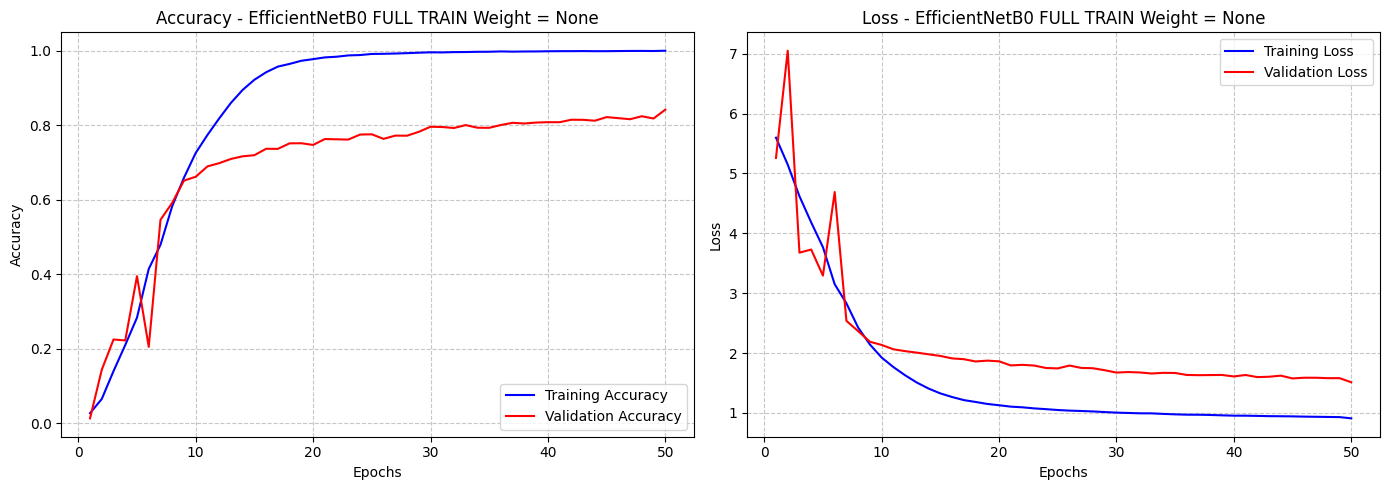

140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step

--- EfficientNetB0 Full Train Weight = None ---
Accuracy : 83.95%
Precision: 0.8490
Recall   : 0.8398
F1-score : 0.8407


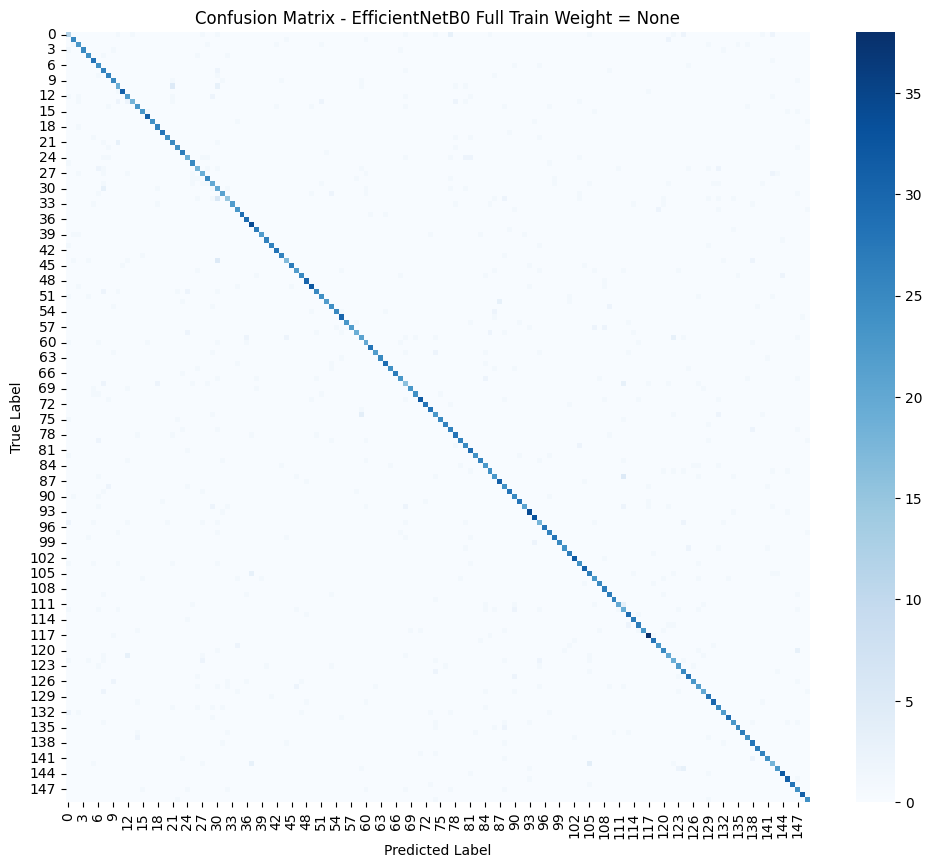

140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step


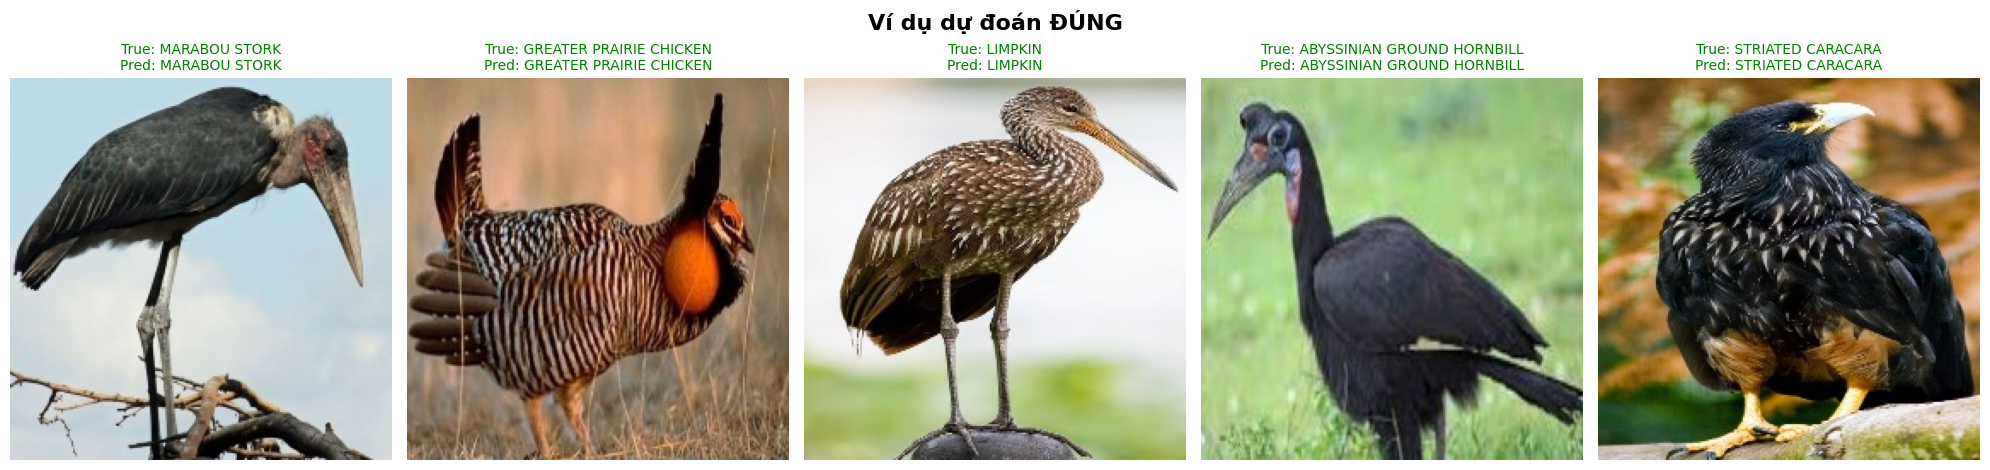

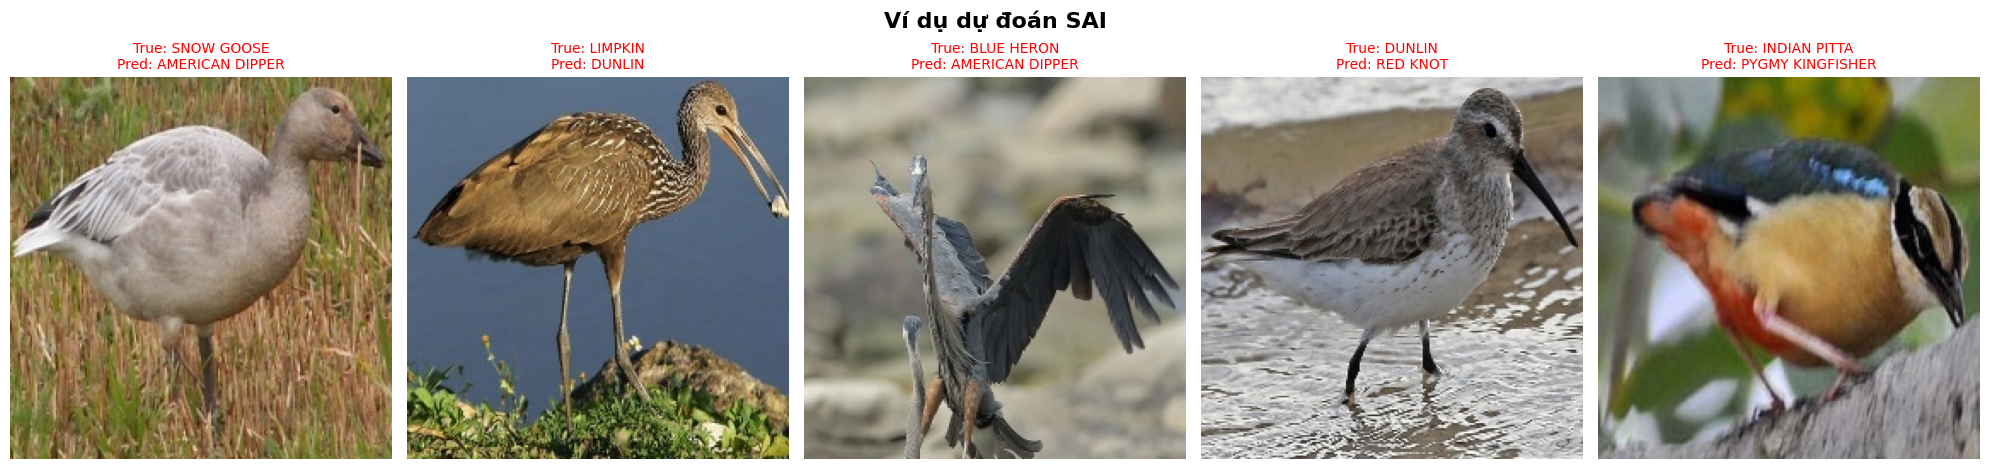

In [14]:
plot_training_history(history_eff, title="EfficientNetB0 FULL TRAIN Weight = None")
evaluate_and_plot(model_eff, test_gen, title="EfficientNetB0 Full Train Weight = None")
plot_sample_predictions(model_eff, test_gen, num_samples=5)